In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [78]:
df = pd.read_csv("dataset_vina.csv")
df.head

<bound method NDFrame.head of              odrůda typ_vína  ročník  cukernatost  kyseliny  alkohol   cena  \
0    Modrý Portugal  červené    2019          NaN      6.35    12.35  281.0   
1         Frankovka  červené    2014        17.71      6.70    13.06  191.0   
2    Modrý Portugal  červené    2017        19.91      5.87    11.02  205.0   
3        Veltlínské     bílé    2015          NaN      6.36    11.30  231.0   
4            Pálava     bílé    2017        19.95      7.20    12.08  246.0   
..              ...      ...     ...          ...       ...      ...    ...   
395          Pálava     bílé    2019        18.97      5.46    12.26  230.0   
396  Rulandské bílé     bílé    2015        24.24      5.88    12.36  262.0   
397       Frankovka  červené    2016        19.09      7.77    13.34  272.0   
398  Modrý Portugal  červené    2017        20.56      6.87    13.27  226.0   
399  Modrý Portugal  červené    2014        14.97      6.53    12.95  194.0   

     hodnocení  
0   

In [79]:
df.isna().sum()


odrůda          0
typ_vína        0
ročník          0
cukernatost    25
kyseliny       20
alkohol        20
cena           20
hodnocení       0
dtype: int64

In [80]:
df["cukernatost"].fillna(df["cukernatost"].median())

0      20.76
1      17.71
2      19.91
3      20.76
4      19.95
       ...  
395    18.97
396    24.24
397    19.09
398    20.56
399    14.97
Name: cukernatost, Length: 400, dtype: float64

In [81]:
dfCukr = df["cukernatost"].fillna(df["cukernatost"].median())
dfCukr.isna().sum()

0

In [82]:
df["cukernatost"] = df["cukernatost"].fillna(df["cukernatost"].median())
df["cena"] = df["cena"].fillna(df["cena"].mean())
df.isna().sum()

odrůda          0
typ_vína        0
ročník          0
cukernatost     0
kyseliny       20
alkohol        20
cena            0
hodnocení       0
dtype: int64

In [83]:
df.groupby("typ_vína")["cena"].mean()

typ_vína
bílé       252.015145
červené    249.668170
Name: cena, dtype: float64

<Axes: ylabel='cena'>

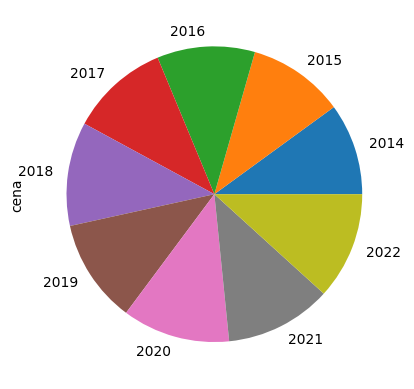

In [84]:
df.groupby("ročník")["cena"].mean()
df.groupby("ročník")["cena"].mean().plot(kind = "pie")

In [85]:
df[df["ročník"] == 2022]

,odrůda,typ_vína,ročník,cukernatost,kyseliny,alkohol,cena,hodnocení
50,Rulandské bílé,bílé,2022,20.72,5.53,11.85,323.0,79.0
71,Svatovavřinecké,červené,2022,19.48,7.03,11.84,213.0,75.4
72,Sauvignon,bílé,2022,20.68,6.44,11.53,213.0,68.5
81,Veltlínské,bílé,2022,22.01,6.17,11.24,289.0,83.0
86,Pálava,bílé,2022,22.43,6.96,12.13,258.0,84.5
90,Svatovavřinecké,červené,2022,15.83,6.55,11.68,246.0,67.8
91,Rulandské bílé,bílé,2022,20.96,5.86,13.78,263.0,80.8
94,Frankovka,červené,2022,24.33,6.91,12.73,297.0,89.2
114,Sauvignon,bílé,2022,21.25,NaN,13.28,298.0,77.3
127,Modrý Portugal,červené,2022,19.88,6.26,12.86,267.0,73.3


In [86]:
df[df["ročník"] == 2022].groupby("odrůda").size()
df[df["ročník"] == 2022].groupby("odrůda").size()["Frankovka"]

5

In [87]:
df[df["ročník"] == 2020].groupby("typ_vína").size()["bílé"]

30

In [88]:
df["type"] = df["cukernatost"].apply(lambda x: "sladke" if x >= 20 else "suche")
df[["cukernatost", "type"]].head()

,cukernatost,type
0,20.76,sladke
1,17.71,suche
2,19.91,suche
3,20.76,sladke
4,19.95,suche


In [89]:
(df["type"] == "suche").sum()


150

<Axes: >

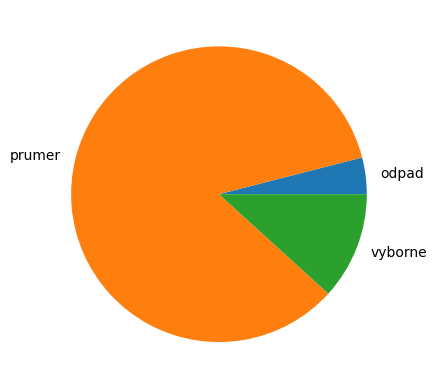

In [90]:
df["znamka"] = df["hodnocení"].apply(
    lambda x: "vyborne" if x >= 90 else ("prumer" if x >= 70 else "odpad")
)
counts = df["znamka"].value_counts()
df.groupby("znamka").size().plot(kind="pie")

<Axes: xlabel='ročník'>

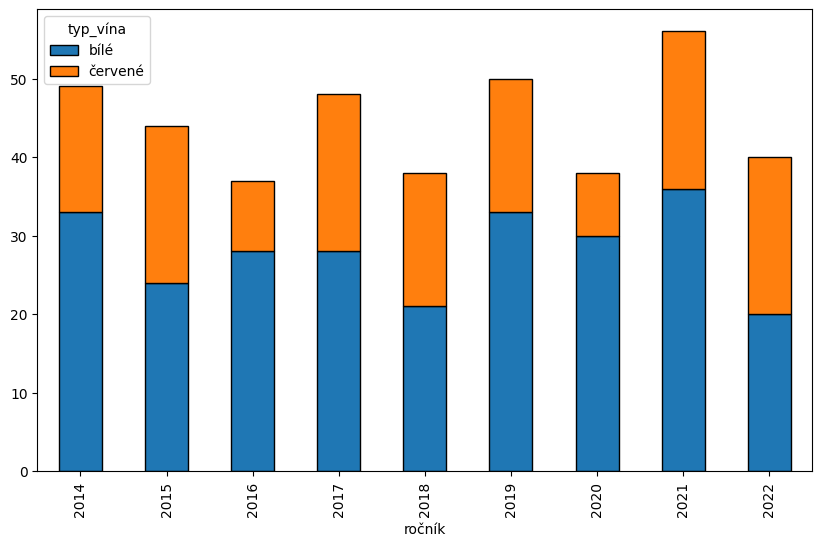

In [91]:
counts = df.groupby(["ročník", "typ_vína"]).size().unstack(fill_value=0)

# Plot as stacked bar chart
counts.plot(kind="bar", stacked=True, figsize=(10,6), edgecolor = "black")

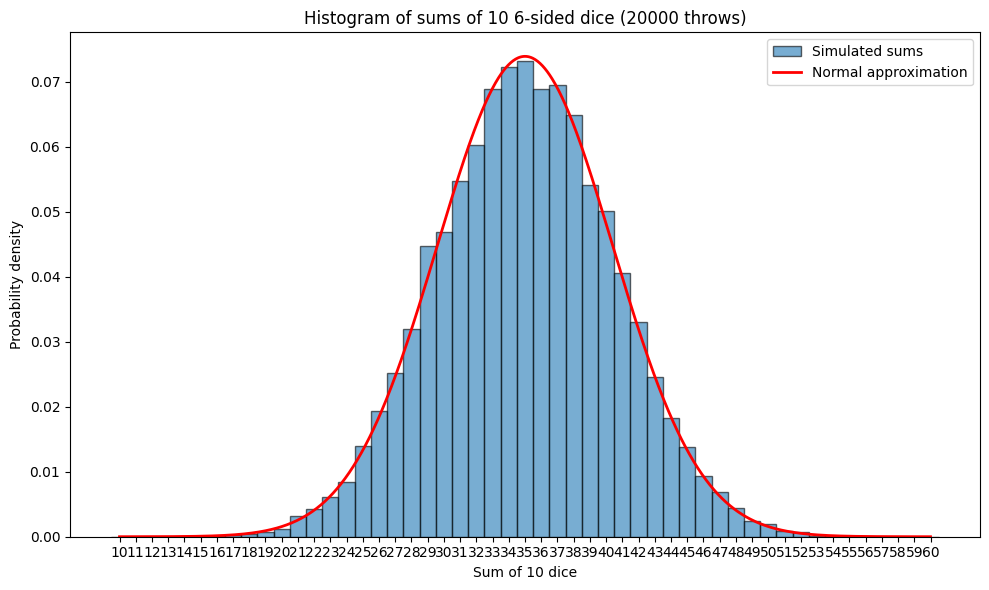

In [103]:
from scipy.stats import norm

def dice_histogram(num_dice=2, sides=6, num_throws=6000):
    """
    Simulate rolling `num_dice` dice with `sides` sides, `num_throws` times,
    and plot a histogram of the sums with the theoretical normal distribution over it.
    """
    # Simulate dice rolls: shape (num_throws, num_dice)
    rolls = np.random.randint(1, sides+1, size=(num_throws, num_dice))
    
    # Sum along each throw
    sums = rolls.sum(axis=1)
    
    # Histogram
    plt.figure(figsize=(10,6))
    count, bins, _ = plt.hist(sums, bins=np.arange(num_dice, num_dice*sides+2)-0.5, 
                              density=True, edgecolor='black', alpha=0.6, label="Simulated sums")
    
    # Theoretical normal distribution parameters
    mu = num_dice * (sides + 1) / 2          # mean
    sigma = np.sqrt(num_dice * (sides**2 - 1) / 12)  # variance formula for uniform(1, sides)
    
    # X values for normal curve
    x = np.linspace(num_dice, num_dice*sides, 1000)
    plt.plot(x, norm.pdf(x, mu, sigma), 'r', lw=2, label="Normal approximation")
    
    plt.xticks(range(num_dice, num_dice*sides+1))
    plt.xlabel(f"Sum of {num_dice} dice")
    plt.ylabel("Probability density")
    plt.title(f"Histogram of sums of {num_dice} {sides}-sided dice ({num_throws} throws)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example: roll 20 six-sided dice 20,000 times
dice_histogram(num_dice=10, sides=6, num_throws=20000)

<Axes: >

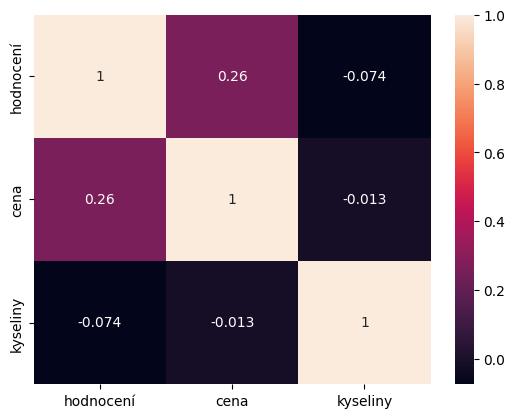

In [112]:
import seaborn as sb
data = df[["hodnocení", "cena", "kyseliny"]]
corrMat = data.corr()
sb.heatmap(corrMat,annot = True)